# 📊 Rekayasa Fitur & Pemodelan Fisik Rantai Pasok Dingin (Cold Chain)

Notebook ini melakukan preprocessing data ritel DataCo, memfilternya untuk wilayah pengiriman domestik AS (Market = `USCA`), serta merumuskan parameter rantai pasok dingin menggunakan model kinetika reaksi Arrhenius (untuk penurunan kualitas produk) dan hukum transfer panas (untuk biaya refrigerasi kontainer pendingin).

## 1. Impor Pustaka & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Memuat dan Memfilter Dataset

Kita memfilter data untuk Market = `USCA` agar pengiriman bersifat domestik dan koordinat lat/long berlokasi di Amerika Utara.

In [2]:
data_path = './data/DataCoSupplyChainDataset.csv'
df = pd.read_csv(data_path, encoding_errors='ignore')

# Filter USCA Market
df_filtered = df[df['Market'] == 'USCA'].copy()
df_filtered['order date (DateOrders)'] = pd.to_datetime(df_filtered['order date (DateOrders)'])
df_filtered = df_filtered.sort_values('order date (DateOrders)')

# Hapus kolom tidak relevan
COLUMNS_TO_DROP = [
    "Customer Email", "Customer Fname", "Customer Lname",
    "Customer Password", "Customer Street", "Customer Zipcode",
    "Customer Id", "Order Customer Id", "Order Id",
    "Order Item Id", "Order Item Cardprod Id",
    "Product Card Id", "Product Image", "Product Description",
    "Product Status", "Category Id", "Department Id",
    "Product Category Id", "Order Zipcode", "Delivery Status"
]
cols_present = [c for c in COLUMNS_TO_DROP if c in df_filtered.columns]
df_filtered.drop(columns=cols_present, inplace=True)

print(f"Shape setelah filter: {df_filtered.shape}")

Shape setelah filter: (25799, 33)


## 3. Perhitungan Jarak (Haversine) & Normalisasi

In [3]:
df_filtered["Delay"] = df_filtered["Days for shipping (real)"] - df_filtered["Days for shipment (scheduled)"]

# Gudang Referensi (AS Tengah)
WAREHOUSE_LAT = 39.8283
WAREHOUSE_LON = -98.5795
EARTH_RADIUS_KM = 6371.0

def haversine_np(lat1, lon1, lat2, lon2):
    phi1, lam1, phi2, lam2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d_phi = phi2 - phi1
    d_lam = lam2 - lam1
    a = np.sin(d_phi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(d_lam / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c

df_filtered["Distance"] = haversine_np(
    df_filtered["Latitude"].values,
    df_filtered["Longitude"].values,
    WAREHOUSE_LAT,
    WAREHOUSE_LON
)

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
delay_clipped = df_filtered["Delay"].clip(lower=0).values.reshape(-1, 1)
dist_vals = df_filtered["Distance"].values.reshape(-1, 1)

scaled = scaler.fit_transform(np.hstack([delay_clipped, dist_vals]))
df_filtered["Delay_norm"] = scaled[:, 0]
df_filtered["Distance_norm"] = scaled[:, 1]

df_filtered["RouteRisk"] = (
    0.4 * df_filtered["Delay_norm"]
    + 0.3 * df_filtered["Distance_norm"]
    + 0.3 * df_filtered["Late_delivery_risk"]
)
print("Jarak dan risiko rute berhasil dihitung.")

Jarak dan risiko rute berhasil dihitung.


## 4. Suhu Ambient & Pemodelan Fisik Cold Chain

In [4]:
df_filtered['day_of_year'] = df_filtered['order date (DateOrders)'].dt.dayofyear
np.random.seed(42)
temp_noise = np.random.normal(0, 1.5, len(df_filtered))
df_filtered['ambient_temp'] = 20.0 + 12.0 * np.sin(2 * np.pi * (df_filtered['day_of_year'] - 80) / 365.0) + temp_noise

# Temperatur target kontainer pendingin berdasarkan moda
shipping_mode_temps_C = {
    "Same Day": 1.0,
    "First Class": 2.0,
    "Second Class": 4.0,
    "Standard Class": 8.0
}
df_filtered['T_container_C'] = df_filtered['Shipping Mode'].map(shipping_mode_temps_C)
df_filtered['T_container_K'] = df_filtered['T_container_C'] + 273.15

# Kinetika Penurunan Kualitas Arrhenius
Q0 = 100.0
Ea = 60000.0
A_decay = 8e9
R_gas = 8.314
k_decay = A_decay * np.exp(-Ea / (R_gas * df_filtered['T_container_K'].values))
t_transit = df_filtered['Days for shipping (real)'].values.astype(float)
t_transit_clipped = np.clip(t_transit, 0.5, None)

df_filtered['QualityDegradation'] = Q0 * np.exp(-k_decay * t_transit_clipped)

# Konsumsi Energi Pendinginan Fisik
P_energy = 0.015
df_filtered['RefrigerationCost'] = P_energy * (df_filtered['ambient_temp'] - df_filtered['T_container_C']) * t_transit_clipped
df_filtered['RefrigerationCost'] = df_filtered['RefrigerationCost'].clip(lower=0.0)

print("Pemodelan Arrhenius & Energi Refrigerasi selesai.")

Pemodelan Arrhenius & Energi Refrigerasi selesai.


## 5. Visualisasi Karakteristik Cold Chain

C:\Users\Legion pro 5\AppData\Local\Temp\ipykernel_35992\437485799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Shipping Mode', y='QualityDegradation', ax=axes[0], palette='Set2')
C:\Users\Legion pro 5\AppData\Local\Temp\ipykernel_35992\437485799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Shipping Mode', y='RefrigerationCost', ax=axes[1], palette='Set2')


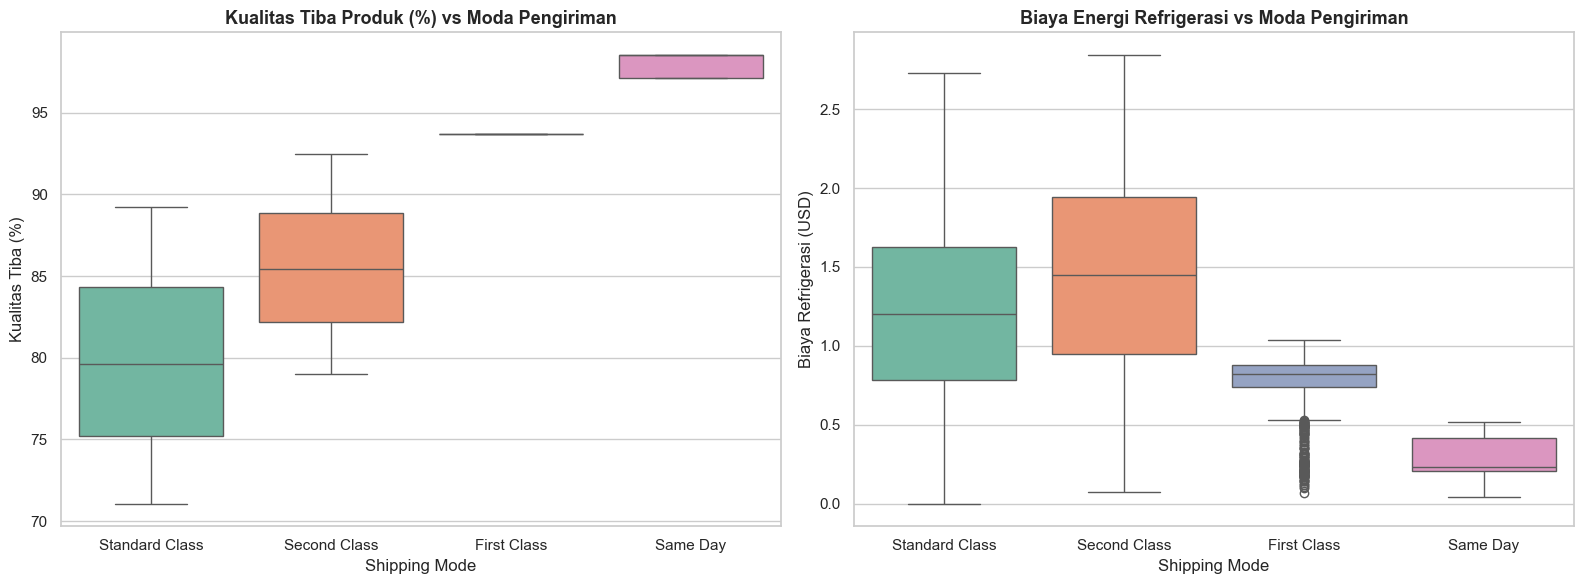

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Kualitas saat tiba berdasarkan moda pengiriman
sns.boxplot(data=df_filtered, x='Shipping Mode', y='QualityDegradation', ax=axes[0], palette='Set2')
axes[0].set_title('Kualitas Tiba Produk (%) vs Moda Pengiriman', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Kualitas Tiba (%)')

# 2. Biaya Refrigerasi berdasarkan moda pengiriman
sns.boxplot(data=df_filtered, x='Shipping Mode', y='RefrigerationCost', ax=axes[1], palette='Set2')
axes[1].set_title('Biaya Energi Refrigerasi vs Moda Pengiriman', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Biaya Refrigerasi (USD)')

plt.tight_layout()
plt.show()

## 6. Ekspor Dataset Akhir

In [6]:
FINAL_COLUMNS = [
    "order date (DateOrders)", "Order Item Quantity", "Sales", "Shipping Mode", "Market",
    "Category Name", "Order Region", "Product Price", "Latitude", "Longitude",
    "Days for shipping (real)", "Days for shipment (scheduled)", "Late_delivery_risk",
    "Delay", "Distance", "Delay_norm", "Distance_norm", "RouteRisk", "ambient_temp",
    "T_container_C", "QualityDegradation", "RefrigerationCost"
]
df_final = df_filtered[FINAL_COLUMNS].copy()
output_dir = './data/processed'
os.makedirs(output_dir, exist_ok=True)
df_final.to_csv(os.path.join(output_dir, 'cold_chain_data.csv'), index=False)
print(f"File berhasil diekspor ke data/processed/cold_chain_data.csv. Shape: {df_final.shape}")

File berhasil diekspor ke data/processed/cold_chain_data.csv. Shape: (25799, 22)
